# Class Imbalance Experiment — Oversampling vs. Class Weights

**Hypothesis:** the baseline's Grad-CAM investigation showed diffuse, unfocused attention on Grade 4 misclassifications — plausibly linked to Grade 4 being both rare (227 images) and visually heterogeneous. Oversampling increases how often the model sees these classes per epoch. If this helps, attention should sharpen and recall should improve on Grade 3/4. If not, that is evidence the bottleneck is genuine data scarcity, not the correction mechanism.

In [1]:
import sys
import tensorflow as tf

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1787829879.924118    1129 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787829880.468281    1129 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787829884.039594    1129 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: /home/yuvika_agrawal/tf_gpu_env/bin/python
TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sys
import os
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

sys.path.append("src/")
from preprocessing import (
    build_paths_labels, build_oversampled_paths_labels, make_dataset,
    full_pipeline_preprocess
)
from data_utils import save_figure

root_dir = "archive"

train_images_dir = os.path.join(root_dir, "train_images", "train_images")
valid_images_dir = os.path.join(root_dir, "val_images", "val_images")
test_images_dir  = os.path.join(root_dir, "test_images", "test_images")

train_df = pd.read_csv(os.path.join(root_dir, "train_clean.csv"))
valid_df = pd.read_csv(os.path.join(root_dir, "valid.csv"))
test_df  = pd.read_csv(os.path.join(root_dir, "test.csv"))

train_paths, train_labels = build_paths_labels(train_df, train_images_dir)
valid_paths, valid_labels = build_paths_labels(valid_df, valid_images_dir)
test_paths, test_labels   = build_paths_labels(test_df, test_images_dir)

# valid_ds / test_ds are IDENTICAL to the baseline notebook
valid_ds = make_dataset(valid_paths, valid_labels, training=False, batch_size=16)
test_ds  = make_dataset(test_paths, test_labels, training=False, batch_size=16)

I0000 00:00:1787834624.862994    1227 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787834625.391245    1227 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787834628.053287    1227 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787834632.011611    1227 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [3]:
#Grade 3 repeated 4x, Grade 4 repeated 3x
oversample_map = {3: 4, 4: 3}

train_paths_os, train_labels_os = build_oversampled_paths_labels(
    train_paths, train_labels, oversample_map
)

print("Original train size:", len(train_paths))
print("Oversampled train size:", len(train_paths_os))
print(pd.Series(train_labels_os).value_counts().sort_index())

assert len(train_paths_os) == len(train_labels_os)

train_ds_os = make_dataset(train_paths_os, train_labels_os, training=True, batch_size=16)

Original train size: 2886
Oversampled train size: 3796
0    1432
1     291
2     784
3     608
4     681
Name: count, dtype: int64


In [6]:
images, labels = next(iter(train_ds_os))


print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)

I0000 00:00:1787834678.081165    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 528 of 3796
I0000 00:00:1787834697.882841    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 1518 of 3796
I0000 00:00:1787834708.049966    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 1770 of 3796
I0000 00:00:1787834718.109997    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 1995 of 3796
I0000 00:00:1787834738.304031    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 2495 of 3796
I0000 00:00:1787834757.903977    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 2976 of 3796
I0000 00:00:1787834777.988288    1887 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuf

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image dtype: <dtype: 'float32'>


In [7]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')
print("Compute dtype:", mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", mixed_precision.global_policy().variable_dtype)

Compute dtype: float16
Variable dtype: float32


In [8]:
def build_model(input_shape=(224, 224, 3), num_classes=5, dropout_rate=0.3):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model

model_os, base_model_os = build_model()
model_os.summary()

E0000 00:00:1787834807.172543    1227 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Phase 1 — frozen backbone, head only

In [10]:
model_os.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:

callbacks_phase1_os = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="outputs/models/phase1_head_oversampled.keras",
        monitor='val_loss', save_best_only=True
    )
]

history_phase1_os = model_os.fit(
    train_ds_os,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks_phase1_os
    # no class_weight here — deliberately testing oversampling alone
)

Epoch 1/20


/home/yuvika_agrawal/tf_gpu_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787830093.731635    1686 service.cc:153] XLA service 0x76deec0676d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787830093.731688    1686 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787830094.036185    1686 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787830095.455941    1686 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787830095.763362    1686 dot_merger.cc

236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5784 - loss: 1.0181

I0000 00:00:1787830121.526560    1686 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28567__.257


238/238 ━━━━━━━━━━━━━━━━━━━━ 83s 242ms/step - accuracy: 0.5782 - loss: 1.0179 - val_accuracy: 0.7077 - val_loss: 0.7455
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.6694 - loss: 0.8035 - val_accuracy: 0.7186 - val_loss: 0.7062
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6878 - loss: 0.7461 - val_accuracy: 0.7295 - val_loss: 0.6878
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7063 - loss: 0.7189 - val_accuracy: 0.7514 - val_loss: 0.6498
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7110 - loss: 0.7090 - val_accuracy: 0.7650 - val_loss: 0.6140
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7231 - loss: 0.6825 - val_accuracy: 0.7596 - val_loss: 0.6187
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7244 - loss: 0.6610 - val_accuracy: 0.7896 - val_loss: 0.5849
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7326 - loss: 0.6555 - val_accuracy: 0.7

## Phase 2 — fine-tune last 30 layers, BatchNorm frozen

In [8]:
model_os.load_weights("outputs/models/phase1_head_oversampled.keras")

base_model_os.trainable = True
fine_tune_at = len(base_model_os.layers) - 30

for layer in base_model_os.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model_os.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

model_os.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2_os = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='outputs/models/phase2_finetuned_oversampled.keras',
        monitor='val_loss', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history_phase2_os = model_os.fit(
    train_ds_os,
    validation_data=valid_ds,
    epochs=40,
    callbacks=callbacks_phase2_os
    # no class_weight here either — same reasoning as Phase 1
)

Epoch 1/40


I0000 00:00:1787830286.042301    1688 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_69819__.271


235/238 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7420 - loss: 0.6382

I0000 00:00:1787830320.932793    1688 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_69819__.271


238/238 ━━━━━━━━━━━━━━━━━━━━ 112s 314ms/step - accuracy: 0.7426 - loss: 0.6362 - val_accuracy: 0.7486 - val_loss: 0.6289 - learning_rate: 1.0000e-05
Epoch 2/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 58s 238ms/step - accuracy: 0.7524 - loss: 0.6217 - val_accuracy: 0.7842 - val_loss: 0.5772 - learning_rate: 1.0000e-05
Epoch 3/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7458 - loss: 0.6100 - val_accuracy: 0.7760 - val_loss: 0.5955 - learning_rate: 1.0000e-05
Epoch 4/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7497 - loss: 0.5978 - val_accuracy: 0.7787 - val_loss: 0.5819 - learning_rate: 1.0000e-05
Epoch 5/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.7603 - loss: 0.5839 - val_accuracy: 0.7842 - val_loss: 0.5758 - learning_rate: 1.0000e-05
Epoch 6/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.7645 - loss: 0.5769 - val_accuracy: 0.7978 - val_loss: 0.5597 - learning_rate: 1.0000e-05
Epoch 7/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accura

W0000 00:00:1787830561.101637    4848 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9633856 bytes after encountering the first element of size 9633856 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


238/238 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.7761 - loss: 0.5509 - val_accuracy: 0.7951 - val_loss: 0.5662 - learning_rate: 5.0000e-06
Epoch 12/40
238/238 ━━━━━━━━━━━━━━━━━━━━ 423s 2s/step - accuracy: 0.7811 - loss: 0.5497 - val_accuracy: 0.7923 - val_loss: 0.5640 - learning_rate: 5.0000e-06


Observation: Class Weights vs Oversampling Execution

The oversampling-based training was noticeably more unstable and computationally expensive than the class-weight-based training. Oversampling increased the number of dataset entries by repeating minority-class samples, especially Grades 3 and 4. As a result, the number of training steps per epoch increased, more samples had to pass through the preprocessing pipeline, more data was cached, and more data was handled by the prefetch pipeline.

Because the current pipeline performs preprocessing before caching, repeated image paths can also result in duplicate processed tensors being stored in the cache. This increases RAM usage without adding new unique images.

In contrast, class weighting keeps the original dataset size unchanged. It adjusts the contribution of each class through the loss function rather than duplicating samples. Therefore, the number of training steps remains smaller, the cache contains only the original dataset entries, and execution times were much more stable.

## Evaluation same as that of the baseline training

In [11]:
model_os.load_weights("outputs/models/phase2_finetuned_oversampled.keras")

test_loss_os, test_accuracy_os = model_os.evaluate(test_ds)
print(f"Test Loss: {test_loss_os:.4f}, Test Accuracy: {test_accuracy_os:.4f}")

/home/yuvika_agrawal/tf_gpu_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(store)
/home/yuvika_agrawal/tf_gpu_env/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(store)
I0000 00:00:1787834923.071387    1702 service.cc:153] XLA service 0x76ad90064df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787834923.073026    1702 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787834923.688544    1702 dump_mlir_util.cc:269] disabling MLIR cr

 1/23 ━━━━━━━━━━━━━━━━━━━━ 8:23 23s/step - accuracy: 0.7500 - loss: 0.5846

I0000 00:00:1787834940.958799    1702 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8087 - loss: 0.4967 
Test Loss: 0.4967, Test Accuracy: 0.8087


              precision    recall  f1-score   support

     Grade 0       0.95      0.98      0.97       199
     Grade 1       0.43      0.33      0.38        30
     Grade 2       0.69      0.80      0.74        87
     Grade 3       0.38      0.35      0.36        17
     Grade 4       0.78      0.42      0.55        33

    accuracy                           0.81       366
   macro avg       0.64      0.58      0.60       366
weighted avg       0.80      0.81      0.80       366

Quadratic Weighted Kappa: 0.8536
Figure saved to: outputs/figures/07_confusion_matrix_oversampled.png


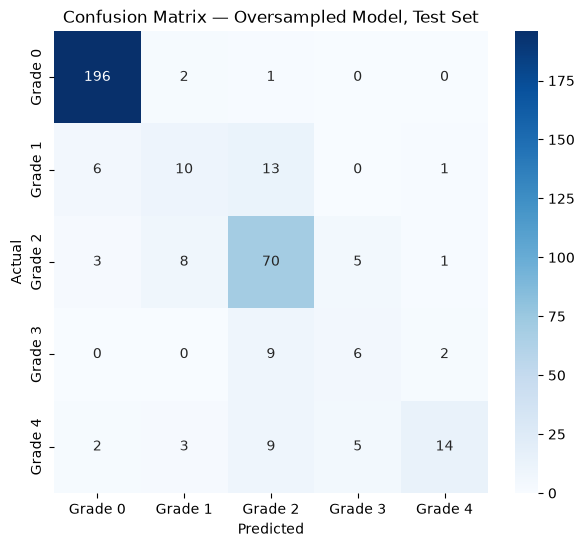

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

y_true_os, y_pred_os = [], []
for images, labels in test_ds:
    preds = model_os.predict(images, verbose=0)
    y_pred_os.extend(np.argmax(preds, axis=1))
    y_true_os.extend(labels.numpy())

y_true_os, y_pred_os = np.array(y_true_os), np.array(y_pred_os)

print(classification_report(y_true_os, y_pred_os, target_names=[f"Grade {i}" for i in range(5)]))

qwk_os = cohen_kappa_score(y_true_os, y_pred_os, weights='quadratic')
print(f"Quadratic Weighted Kappa: {qwk_os:.4f}")

cm_os = confusion_matrix(y_true_os, y_pred_os)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_os, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Grade {i}" for i in range(5)],
            yticklabels=[f"Grade {i}" for i in range(5)], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Oversampled Model, Test Set")
save_figure(fig, "outputs/figures/07_confusion_matrix_oversampled.png")
plt.show()

Oversampling improved overall accuracy, weighted F1, Grade 2 performance, Grade 4 performance, and QWK. However, it caused a substantial drop in Grade 1 recall and did not meaningfully improve Grade 3 F1. Class weighting produced slightly lower overall accuracy but better macro recall and more stable minority-class detection, particularly for Grade 1 and Grade 3.

In [13]:
baseline_qwk = 0.8258
baseline_recall = {0: 0.97, 1: 0.67, 2: 0.66, 3: 0.41, 4: 0.33}

report_os = classification_report(y_true_os, y_pred_os, target_names=[f"Grade {i}" for i in range(5)], output_dict=True)
oversampled_recall = {i: report_os[f"Grade {i}"]["recall"] for i in range(5)}

comparison = pd.DataFrame({
    "Baseline (class weights)": {**{f"Grade {i} recall": baseline_recall[i] for i in range(5)}, "QWK": baseline_qwk},
    "Oversampled": {**{f"Grade {i} recall": oversampled_recall[i] for i in range(5)}, "QWK": qwk_os},
})
print(comparison)

                Baseline (class weights)  Oversampled
Grade 0 recall                    0.9700     0.984925
Grade 1 recall                    0.6700     0.333333
Grade 2 recall                    0.6600     0.804598
Grade 3 recall                    0.4100     0.352941
Grade 4 recall                    0.3300     0.424242
QWK                               0.8258     0.853558


The oversampled model improves Grades 2 and 4, but it severely hurts Grade 1 and slightly hurts Grade 3. Grade 2 seems to have the most benefit of it all. 
More exposure to a minority class does not necessarily mean better discrimination if the classes themselves are visually similar or the minority dataset lacks sufficient diversity.

GradCam recheck

In [14]:
def get_head_layers(m):
    gap_layer, dense_layer = None, None
    for layer in m.layers:
        if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            gap_layer = layer
        elif isinstance(layer, tf.keras.layers.Dense):
            dense_layer = layer
    return gap_layer, dense_layer


def make_gradcam_heatmap(img_array, m, bm, last_conv_layer_name="top_activation", pred_index=None):
    last_conv_layer = bm.get_layer(last_conv_layer_name)

    conv_model = tf.keras.models.Model(
        inputs=bm.input,
        outputs=[last_conv_layer.output, bm.output]
    )

    gap_layer, dense_layer = get_head_layers(m)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_output = conv_model(img_array, training=False)
        x = gap_layer(backbone_output)
        predictions = dense_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    conv_outputs = tf.cast(conv_outputs[0], tf.float32)
    grads = tf.cast(grads, tf.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def overlay_heatmap(img_uint8, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)

In [21]:
misclassified_mask_os = (y_true_os == 4) & (y_pred_os == 0)
misclassified_indices_os = np.where(misclassified_mask_os)[0]
print(f"Found {len(misclassified_indices_os)} Grade 4 -> Grade 0 misclassifications (oversampled model)")
print("Test paths:", [test_paths[i] for i in misclassified_indices_os])

Found 2 Grade 4 -> Grade 0 misclassifications (oversampled model)
Test paths: ['archive/test_images/test_images/e9ab8413e771.png', 'archive/test_images/test_images/f549294e12e1.png']


In [26]:
def visualize_gradcam_samples(indices, paths, true_labels, pred_labels,  title_prefix=""):
    if len(indices) == 0:
        print("No samples to visualize.")
        return
    fig, axes = plt.subplots(len(indices), 2, figsize=(8, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        img_path = paths[idx]
        img_bgr = cv2.imread(img_path)
        processed = full_pipeline_preprocess(img_bgr)
        img_input = np.expand_dims(processed, axis=0)

        heatmap, pred_class = make_gradcam_heatmap(img_input, model_os, base_model_os)

        display_img = np.clip(processed, 0, 255).astype(np.uint8)
        overlayed = overlay_heatmap(display_img, heatmap)

        axes[row, 0].imshow(display_img)
        axes[row, 0].set_title(f"{title_prefix} True={true_labels[idx]}, Pred={pred_labels[idx]}", fontsize=9)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(overlayed)
        axes[row, 1].set_title("Grad-CAM", fontsize=9)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


visualize_gradcam_samples(misclassified_indices_os, test_paths, y_true_os, y_pred_os,model_os, base_model_os, title_prefix="OVERSAMPLED-MISCLASSIFIED")

# correctly classified Grade 4 cases
correct_grade4_indices = np.where((y_true_os == 4) & (y_pred_os == 4))[0][:3]
visualize_gradcam_samples(correct_grade4_indices, test_paths, y_true_os, y_pred_os, title_prefix="CORRECT")

TypeError: visualize_gradcam_samples() got multiple values for argument 'title_prefix'